# HackAI 2026 | Unsupervised LSTM Autoencoder for Jet Engine Fault Detection

Neil Ghugare, Nishanth Kunchala, and Jacob Balek


**Important distinction! From here on out, the term "failure" refers to the official failure of the engine, where it can no longer function properly. The term "fault" refers to the point where the engine first develops a fault, but is still able to run until eventually reaching failure.**

### Imports and Data Fetching

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub as kh
import os
import keras
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from helper import *
from keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Input
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from IPython.display import Image, display

%matplotlib inline

In [2]:
# Boolean that can be toggled on/off to do training in the notebook
training = False

We set a random seed to ensure reproducible results with Tensorflow randomization and weight-setting. We then fetch the data using KaggleHub via KaggleAPI and then read it into the standard Pandas `DataFrame`.

In [3]:
tf.random.set_seed(42)

In [4]:
path = kh.dataset_download("palbha/cmapss-jet-engine-simulated-data")

We utilize the data's [README](https://www.kaggle.com/datasets/palbha/cmapss-jet-engine-simulated-data?select=readme.txt) to see that our columns will be the unit (which engine number), the cycle, then three operational settings (defining what regime the plane flew in like Mach speed), and then multiple sensor measurements.

In [5]:
col_names = ['Unit', 'Cycle Time', 'Op1', 'Op2', 'Op3'] + [f'Sensor {_+1}' for _ in range(23)]
df = pd.read_csv(os.path.join(path, 'train_FD001.txt'), sep=' ', header=None, names=col_names)
df_test = pd.read_csv(os.path.join(path, 'test_FD001.txt'), sep=' ', header=None, names=col_names)

In [6]:
df.head()

,Unit,Cycle Time,Op1,Op2,Op3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Sensor 22,Sensor 23
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN


### Exploratory Data Analysis

The following code outputs the data into a text file with a nice Markdown-style format so we can actually see the `describe` results (because it is hard to see or read in the cell output).

In [7]:
# Using to_string with specific formatting
with open('data_summary_FD001.txt', 'w') as f:
    f.write("CMAPSS Dataset Summary Statistics\n")
    f.write("="*30 + "\n")
    f.write(df.describe().transpose().to_string()) # Transpose makes it easier to read due to many sensors

Now we will use Seaborn to examine the operational settings and the sensor data. In this first plot, we will look at all of them as a function of the cycle time.

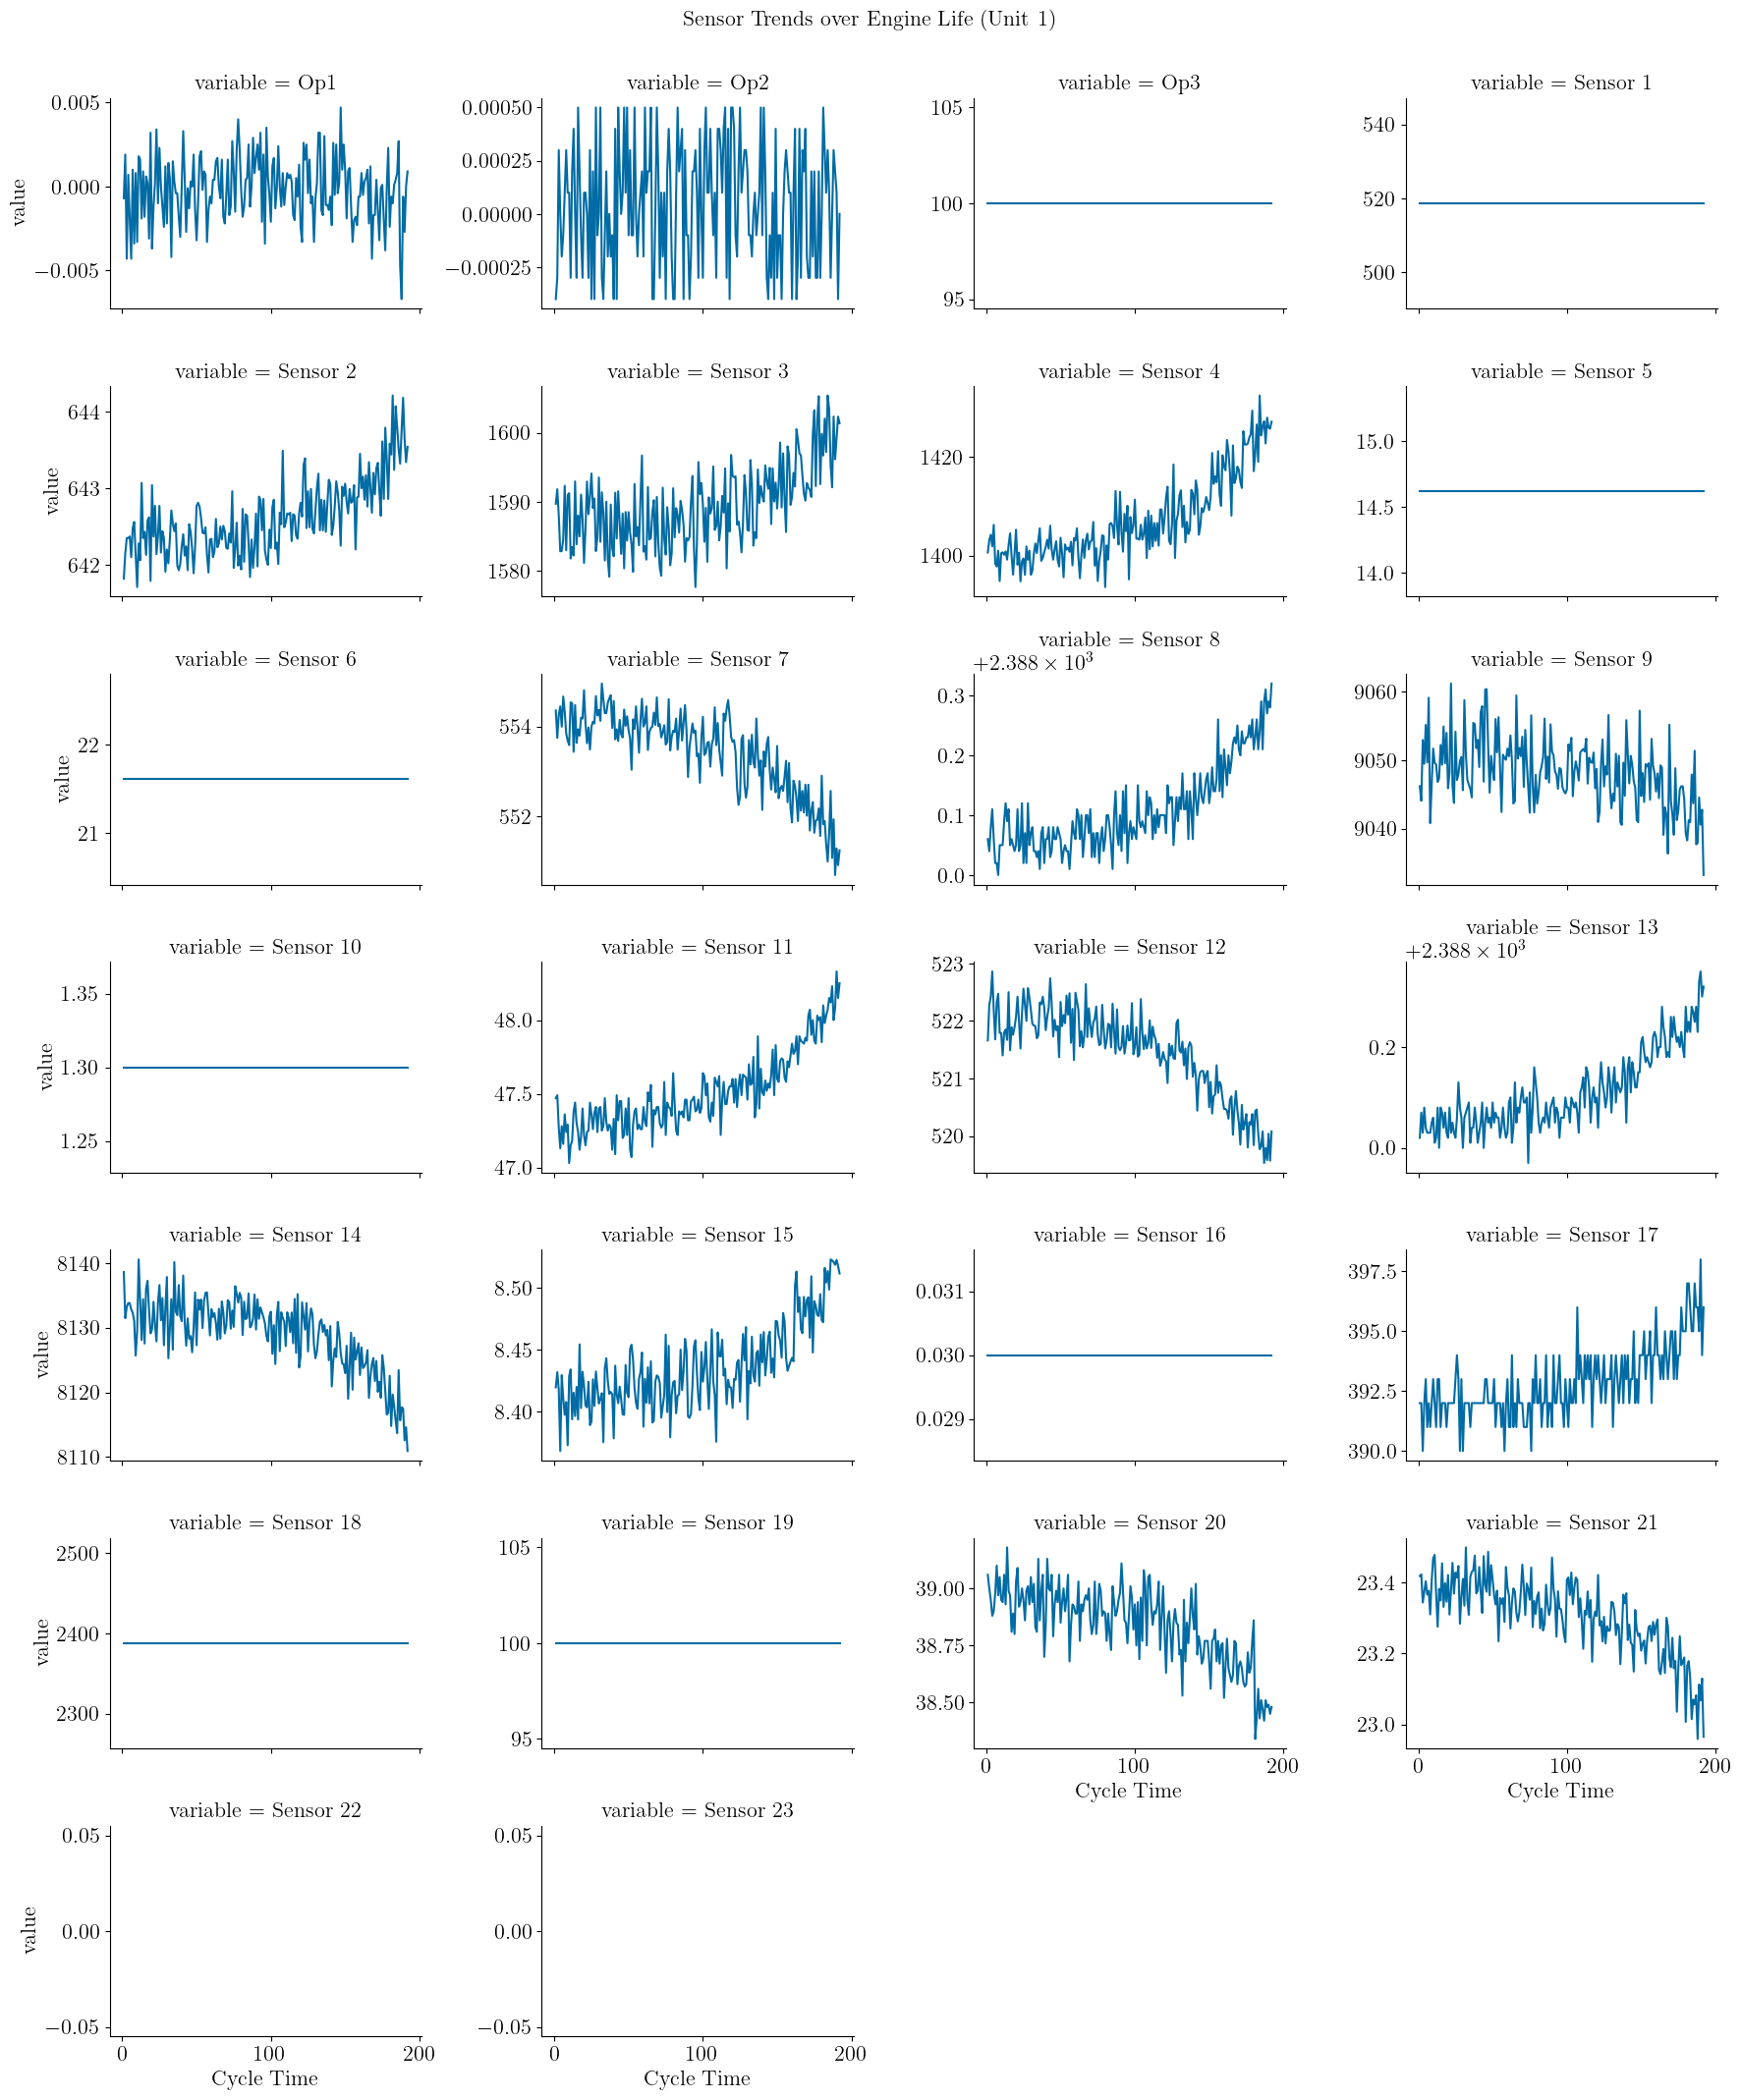

In [8]:
fig = sensor_explore_plot(df, ids='Cycle Time', values=['Op1', 'Op2', 'Op3'] + [f'Sensor {_+1}' for _ in range(23)])
plt.show()

From the above plot, any sensor that is flat is either not in use or does not change during the lifetime of the engine. Those are unnecessary columns for the autoencoder to reconstruct, and thus we can safely drop them. In general, we don't want to drop the operational settings, but since the third one is constant, we *do* elect to drop that one.

In [9]:
cols_to_drop = ['Sensor 1', 'Sensor 5', 'Sensor 6', 'Sensor 10', 'Sensor 16', 'Sensor 17', 'Sensor 18', 'Sensor 19', 'Sensor 22', 'Sensor 23']
relevant_sensors = [f'Sensor {_+1}' for _ in range(23) if _ not in (0, 4, 5, 9, 15, 16, 17, 18, 21, 22)]
ops = ['Op1', 'Op2']
df = df.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)
df.head()

,Unit,Cycle Time,Op1,Op2,Op3,Sensor 2,Sensor 3,Sensor 4,Sensor 7,Sensor 8,Sensor 9,Sensor 11,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 20,Sensor 21
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,38.90,23.4044


Now when we make the Seaborn plot, we will see only the variables that have significant impacts on the failure and fault.

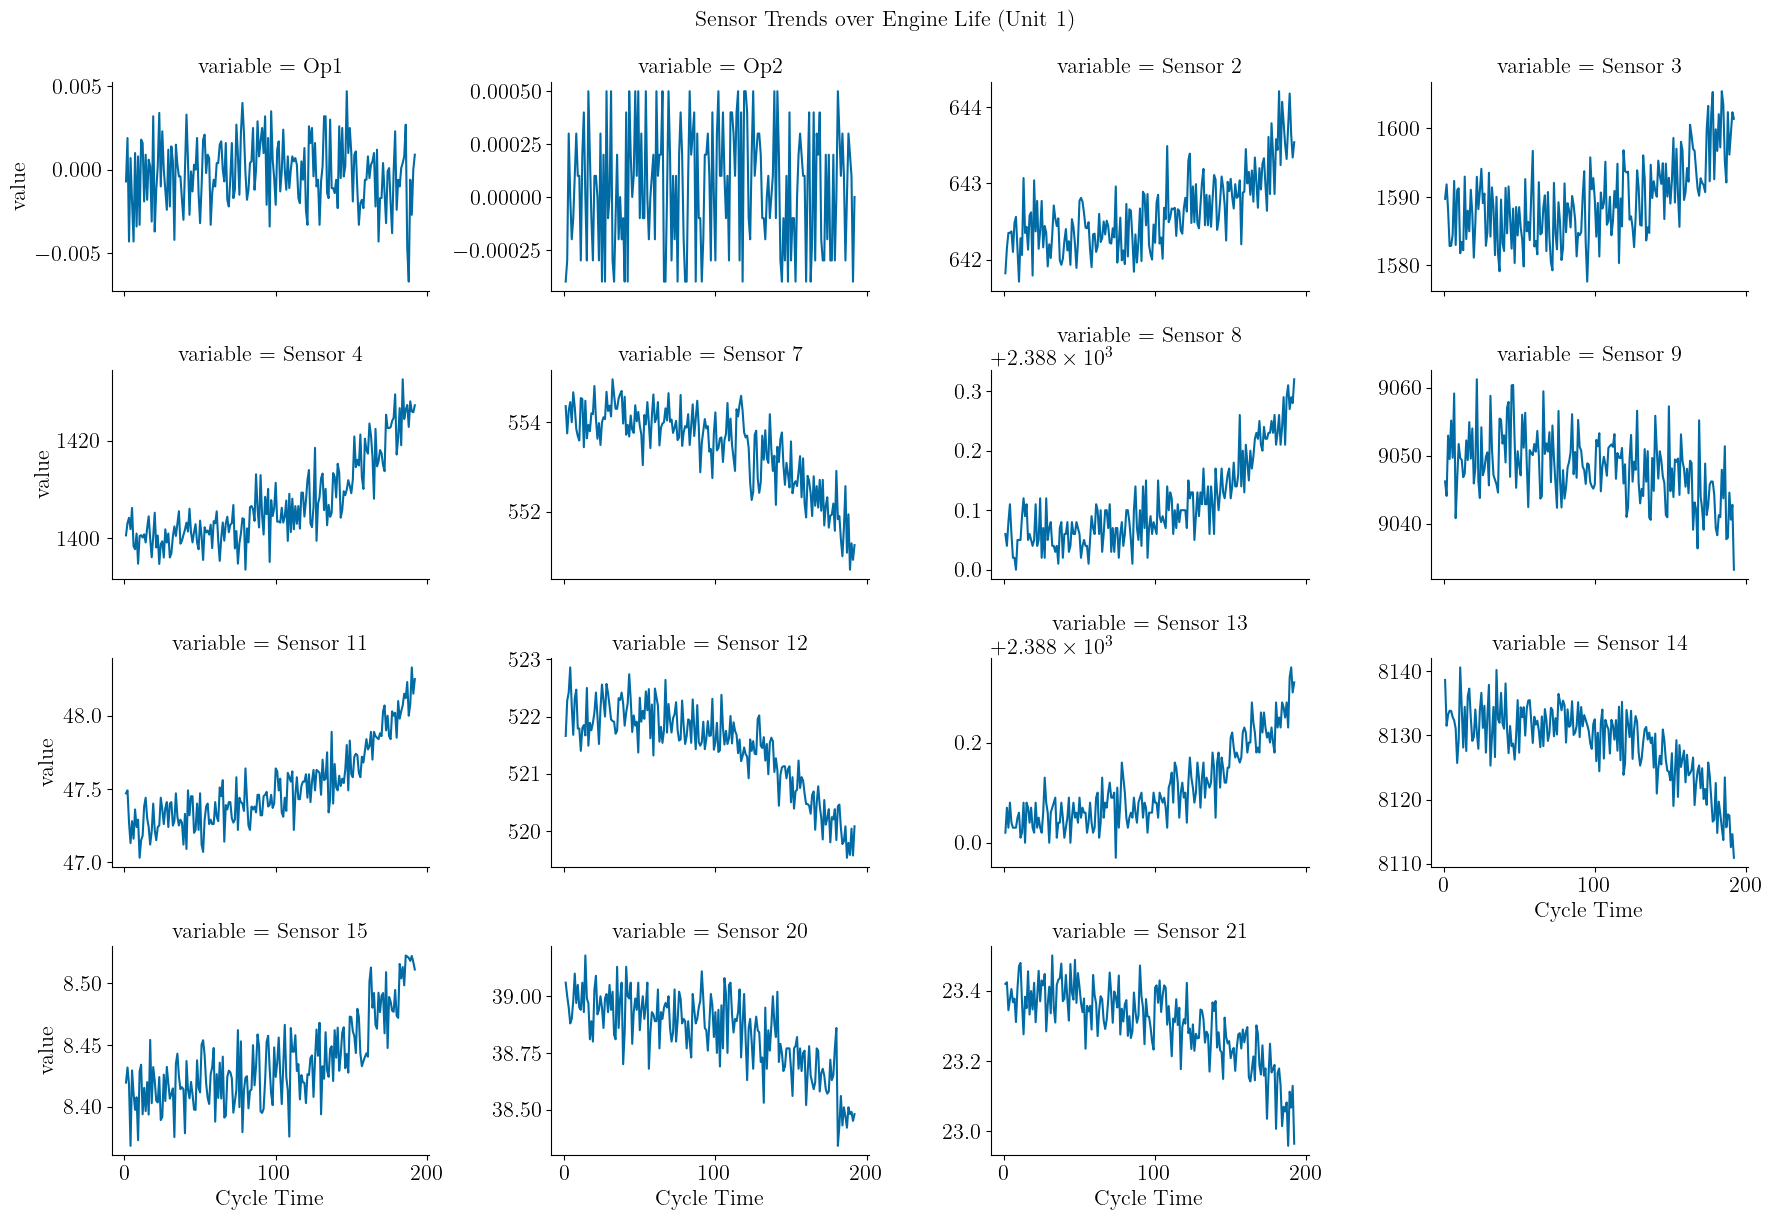

In [10]:
fig = sensor_explore_plot(df, ids='Cycle Time', values=ops+relevant_sensors)
plt.show()

One thing we wish to define is the *window size*, how many cycles the autoencoder will look at durign one reconstruction. We set this value to 50. We then use `MinMaxScaler` to normalize the data set for better usage.

In [11]:
wsize = 50

# Fit ONLY on the first 50 cycles of the training data 
# This defines the 0.0 to 1.0 range based on HEALTHY engines
scaler = MinMaxScaler()
scaler.fit(df.groupby('Unit').head(wsize)[ops + relevant_sensors])

# Transform everything using that "Healthy Range"
df[ops + relevant_sensors] = scaler.transform(df[ops + relevant_sensors])
df_test[ops + relevant_sensors] = scaler.transform(df_test[ops + relevant_sensors])

We generate the train and test sets. See the `helper.py` file for the definitions and doc comments for these functions (and many more functions in this file). One important distinction is that we separate the operational settings from the sensors. In doing so, our data will have the operation settings inputted into the model, but will only output sensor data. Remember that the operational settings are things like altitude or Mach speed. It is not important for our autoencoder to reconstruct these as they have no direct relation to fault detection; They are just the current setting of a flight. 

In [12]:
X_train, Y_train = gen_train_windows_multi(df, wsize, ops, relevant_sensors)
X_test, Y_test, test_units = gen_test_windows_multi(df_test, wsize, ops, relevant_sensors)

From the shape, we can directly see this separation. The input (`X_train`) has a final column value of 15, which accounts for the 13 sensors plus 2 operational settings. The output only has 13, which accounts for the reconstruction of the 13 sensors (we don't care about reconstructing the operational settings).

In [13]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(100, 50, 15)
(100, 50, 13)
(93, 50, 15)
(93, 50, 13)


### Model

Now we move on to building the model utilizing Tensorflow's functional API. We create an LSTM autoencoder, taking the operational settings and relevant sensors as input. We apply an LSTM encodation the the data, bottlenecking it to force feature extraction with `RepeatVector` and then decoding it with an LSTM later.  

In [14]:
# Define dimensions based relevant lists
n_inputs = len(ops) + len(relevant_sensors)  # Total features in X_train
n_targets = len(relevant_sensors)            # Only the sensors in Y_train

# 1. Input Layer
# Matches the shape (window_size, total_features)
inputs = Input(shape=(wsize, n_inputs))

# 2. Encoder
# Processes both Ops and Sensors to find the 'hidden' health state
encoder = LSTM(64, activation='tanh', return_sequences=False)(inputs)

# 3. Bottleneck
# Bridges the single 'thought vector' back into a sequence
bottleneck = RepeatVector(wsize)(encoder)

# 4. Decoder
decoder = LSTM(64, activation='tanh', return_sequences=True)(bottleneck)

# 5. Output Layer
# This MUST match n_targets so it only reconstructs the relevant sensors
outputs = TimeDistributed(Dense(n_targets))(decoder)

# Create the Model object
model = keras.models.Model(inputs=inputs, outputs=outputs)

# Compile
model.compile(optimizer='adam', loss='mae')

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50, 15)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 50, 13)         │           845 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,349 (212.30 KB)

 Trainable params: 54,349 (212.30 KB)

 Non-trainable params: 0 (0.00 B)

We now train the model. We utilize `EarlyStopping` and `ModelCheckpoint` callbacks to get the best possible results from our training step.

In [15]:
callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=5),
             keras.callbacks.ModelCheckpoint(filepath='best_model_fd001.keras', monitor='val_loss', save_best_only=True)]

if training:
    history = model.fit(
        X_train, Y_train, 
        epochs=50, 
        batch_size=32, 
        validation_split=0.1, 
        verbose=1,
        callbacks=callbacks
    )

We now make the necessary loss vs. epoch plot. From this, we get a good general shape.

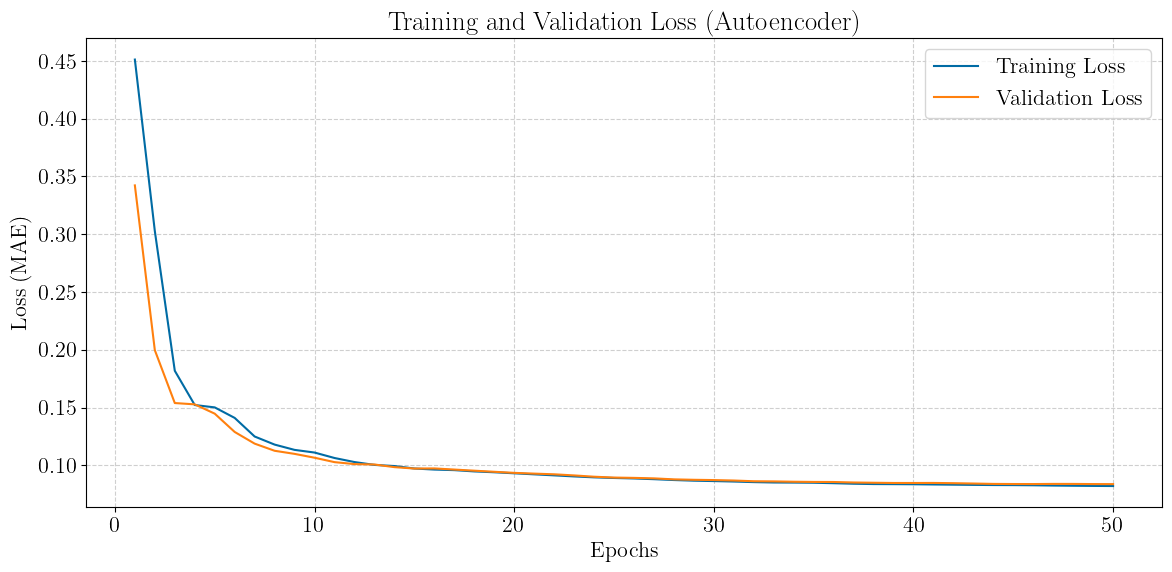

In [16]:
if training:
    fig = make_loss_plot(history)
    plt.show()
else:
    display(Image(filename='loss_fd001.png'))

We load the best model from the model checkpoint to use from here on out.

In [17]:
model = keras.models.load_model('best_model_fd001.keras')

Now we can define the threshold of being above the 97.5th percentile above this mean ground error from reconstruction. We do *not* define this as 2 standard deviations because our error is not likely to be Gaussian distributed (usually having a longer tail). Doing a percentile method keeps everything consistent, regardless of distribution type. From this, we get our quiet failure threshold.

In [18]:
Y_train_pred = model.predict(X_train)
train_mae_loss = np.mean(np.abs(Y_train_pred - Y_train), axis=(1, 2))

# Set the threshold: Anything 3 standard deviations above the mean error is a "Failure"
threshold = np.percentile(train_mae_loss, 97.5)

print(f"Quiet Failure Threshold: {threshold}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Quiet Failure Threshold: 0.08669556533508323


Below is a plot of the distribution of the train set's MAE loss per window as a function of the window's reconstruction error. We see where the threshold lies. The point of this distribution is to show that most of the reconstruction error is around the mean/median, and not having a mean due to large amounts of windows with low reconstruction error and high reconstruction error cancelling each other out.

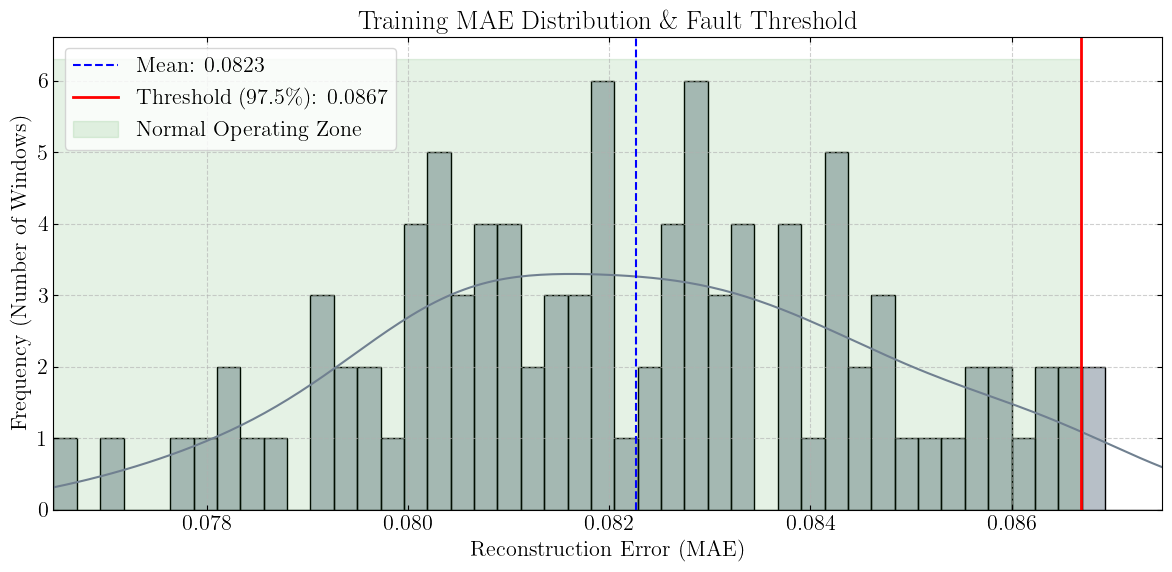

In [19]:
fig = plot_threshold_justification(train_mae_loss, threshold)
plt.show()

We can now see if an engine fault has occurred by seeing if the test MAE loss ever crosses the threshold over cycle time. 

In [20]:
anomaly_score = failure_detection(df_test, model, 3, threshold, wsize, ops, relevant_sensors)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
No Failure detected above threshold.


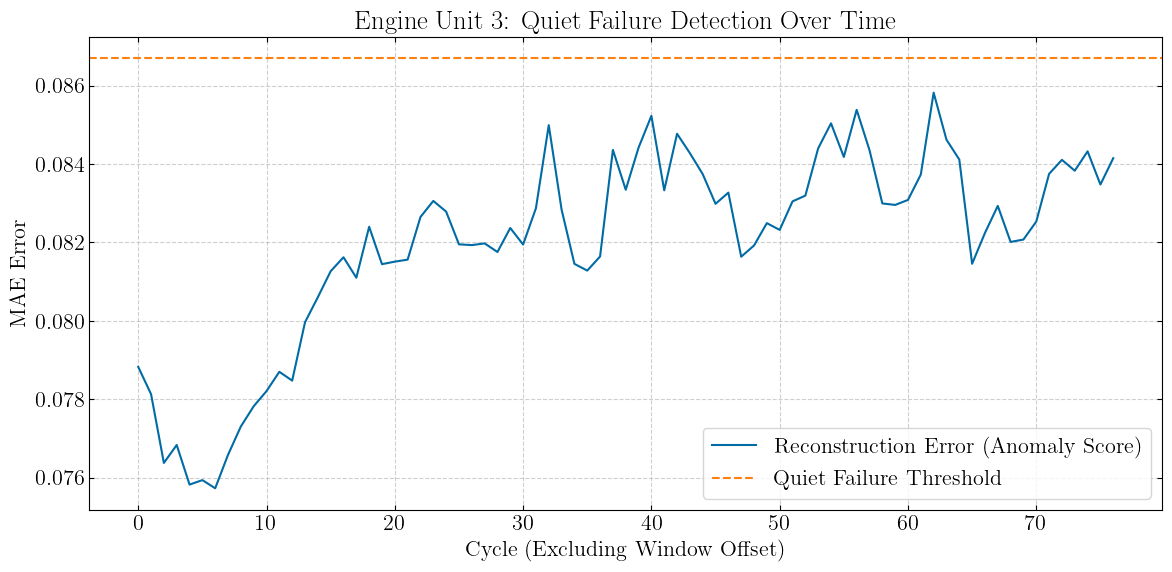

In [21]:
fig = failure_plot(anomaly_score, threshold, unit_no=3)
plt.show()

In [22]:
anomaly_score = failure_detection(df_test, model, 17, threshold, wsize, ops, relevant_sensors)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Quiet Failure detected at Cycle: 60


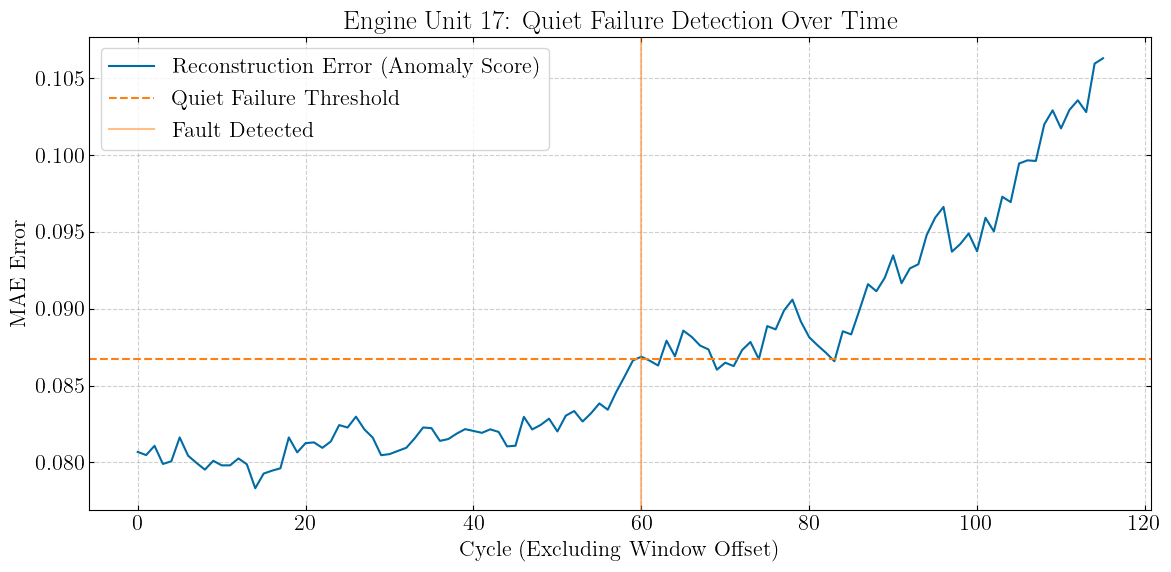

In [23]:
fig = failure_plot(anomaly_score, threshold, unit_no=17)
plt.show()

This is unsupervised, so we have no way of actually knowing if the fault has indeed occurred at the point identified. There is a way, however, we can be relatively certain quantitatively the our model is doing a good job. The test data has known RUL values, or Remaining Useful Life, which is the amount of cycles the test engine has left *at the end of the test data* (i.e. an RUL of 8 means 8 cycles after the end of the data, the machine should fail). 

We can then first qualitatively judge how good our model is. The maximum anomaly score MAE should be higher for engines with small RUL values (they are close to failing). Engines with high RUL values (long time until they fail) should have low anomaly scores. This relationship may not necessarily be linear. We do this with the `generate_audit_results` and `anomaly_rul_plot`.

In [24]:
rul_truth = pd.read_csv(os.path.join(path, 'RUL_FD001.txt'), header=None).values.flatten()

audit_df = generate_audit_results(df_test, rul_truth, model, wsize, ops, relevant_sensors)

print("Top 10 Engines with Highest Anomaly Scores:")
audit_df.head(10)

Top 10 Engines with Highest Anomaly Scores:


,Unit,Max_Anomaly_Score,Actual_RUL
19,24,0.203512,20
92,100,0.191683,20
69,76,0.163057,10
59,66,0.159488,14
25,31,0.152690,8
29,35,0.145492,11
74,81,0.144017,8
61,68,0.133776,8
28,34,0.131461,7
35,42,0.128790,10


0.07896455174936377 0.031590467300512105 0.08329791227795336


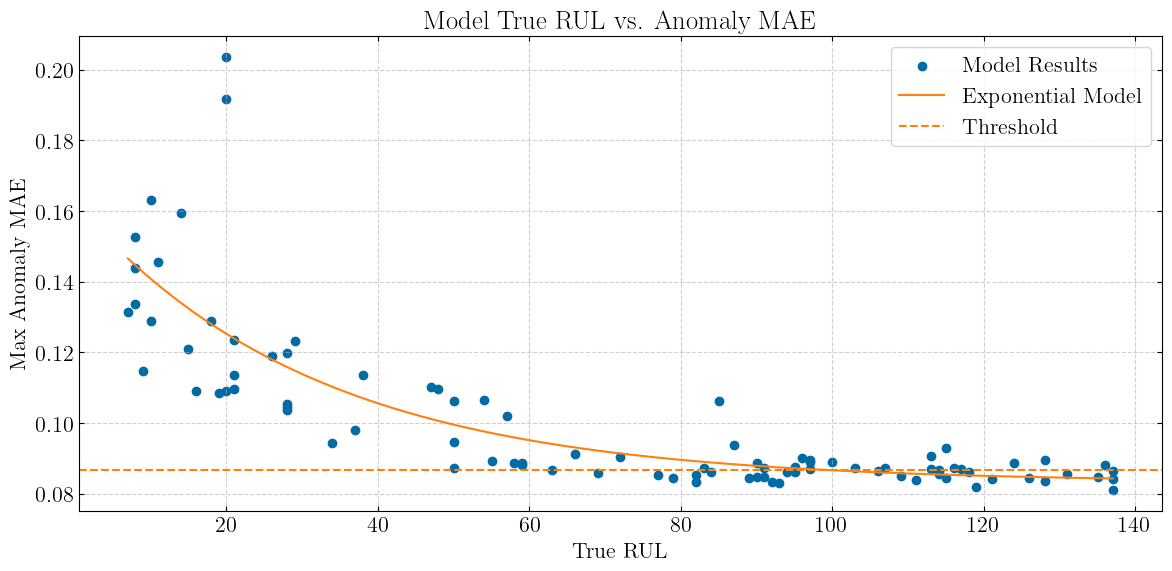

In [25]:
fig = anomaly_rul_plot(audit_df, threshold)
plt.show()

We can see in general we get the expected result, that the MAE decreases with increasing RUL. We also see the increase in number of points below the threshold as we increase the true RUL. This is exactly the qualitative result we would expect.

Now we can put a quantitative measurement to this using the [Spearman correlation](https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient). This correlation is like a standard (Pearson) correlation, which checks for a straight line relationship. Spearman checks if one variable goes up when the other goes down, regardless of whether that relationship is curved/exponential/etc. It is given by the formula:
$$
r_{\rm S} = 1 - \frac{6 \sum_i d^2_i}{n(n^2-1)},
$$
where $d_i$ is the difference between the rank of the $i^{\rm th}$ anomaly score and $i^{\rm th}$ RUL value, and $n$ is the number of observations/data points. 

In simple terms, it looks at the order of our data. If the highest anomaly score happens at the lowest RUL, the second highest score at the second lowest RUL, and so on, you get a perfect correlation of -1.0, regardless of the shape. This means any monotonically decreasing relation gets this perfect correlation. We would like our value to be as close to -1.0 as possible. We do recognize that a perfect inverse relationship is not feasible due to sensor noise, regime switching during a cycle, or normal variance during the healthy plateau (right hand side of graph).

So, what does this do for our model? It proves that our autoencoder isn't just seeing random noise, and that it is indeed seeing an engine "get sicker" over time. It handles the exponential curve that we see above, since engine failure accelerates near the end of its lifetime, making it more accurate than a simple Pearson correlation. It also quantitatively ensures that the relationship we're seeing is in fact the true relationship between MAE and RUL. 

In [26]:
# 1. Using Pandas (Quickest way)
spearman_corr = audit_df['Actual_RUL'].corr(audit_df['Max_Anomaly_Score'], method='spearman')
print(f"Spearman Correlation: {spearman_corr:.4f}")

# 2. Using SciPy (Gives you a p-value for scientific proof)
rho, p_value = spearmanr(audit_df['Actual_RUL'], audit_df['Max_Anomaly_Score'])

print(f"Spearman's rho: {rho:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("The correlation is statistically significant.")

Spearman Correlation: -0.7934
Spearman's rho: -0.7934
P-value: 2.5027e-21
The correlation is statistically significant.


We get a very good Spearman correlation of -0.79, which is statistically significant result, numerically confirming our trend. This shows that the autoencoder in general is returning results that make sense given the known RUL values. It's good to note that this is an extremely simple approach to this data set, but since it's a more trivial data set, we still get a very good Spearman correlation.

### Do It Again

All of the above work was for the data `FD001`. There is one huge problem with this dataset: it's extremely idealistic. As indicated in the [README](https://www.kaggle.com/datasets/palbha/cmapss-jet-engine-simulated-data?select=readme.txt), the `FD001` dataset only has 1 condition and one fault mode. A condition is any condition for the running of the engine, with the one condition indicating it is operated only at sea level (constant ambient temperature and pressure with constant throttle). It also only has one fault mode, meaning only sensors related to the compressor (HPC) can degrade.

Our result is great, but is not realistic, or real-world usable. Instead, we redo this with `FD004`. This dataset is the *most* realistic, containing 6 categories the engine runs (e.g., changing ambient weather), and has two fault modes (both the HPC can degrade as well as the engine fan). 

We will have to take a completely different approach, but this one will ensure we get good results.

In [27]:
columns = ['Unit', 'Cycle Time', 'setting1', 'setting2', 'setting3'] + [f's_{i}' for i in range(1, 22)]
df = pd.read_csv(f"{path}/train_FD004.txt", sep='\s+', header=None, names=columns)
df_test = pd.read_csv(f"{path}/test_FD004.txt", sep='\s+', header=None, names=columns)
HEALTHY_RUL_THRESHOLD = 125

In [28]:
df.head()

,Unit,Cycle Time,setting1,setting2,setting3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


We define a `HEALTHY_RUL_THRESHOLD` (with values coming from literature, e.g., [IEEE](https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=7998311)). NISH PLEASE

In [29]:
HEALTHY_RUL_THRESHOLD = 130

We once again check summary statistics and make Seaborn plots!

In [30]:
# Using to_string with specific formatting
with open('data_summary_FD004.txt', 'w') as f:
    f.write("CMAPSS Dataset Summary Statistics\n")
    f.write("="*30 + "\n")
    f.write(df.describe().transpose().to_string()) # Transpose makes it easier to read if you have many sensors

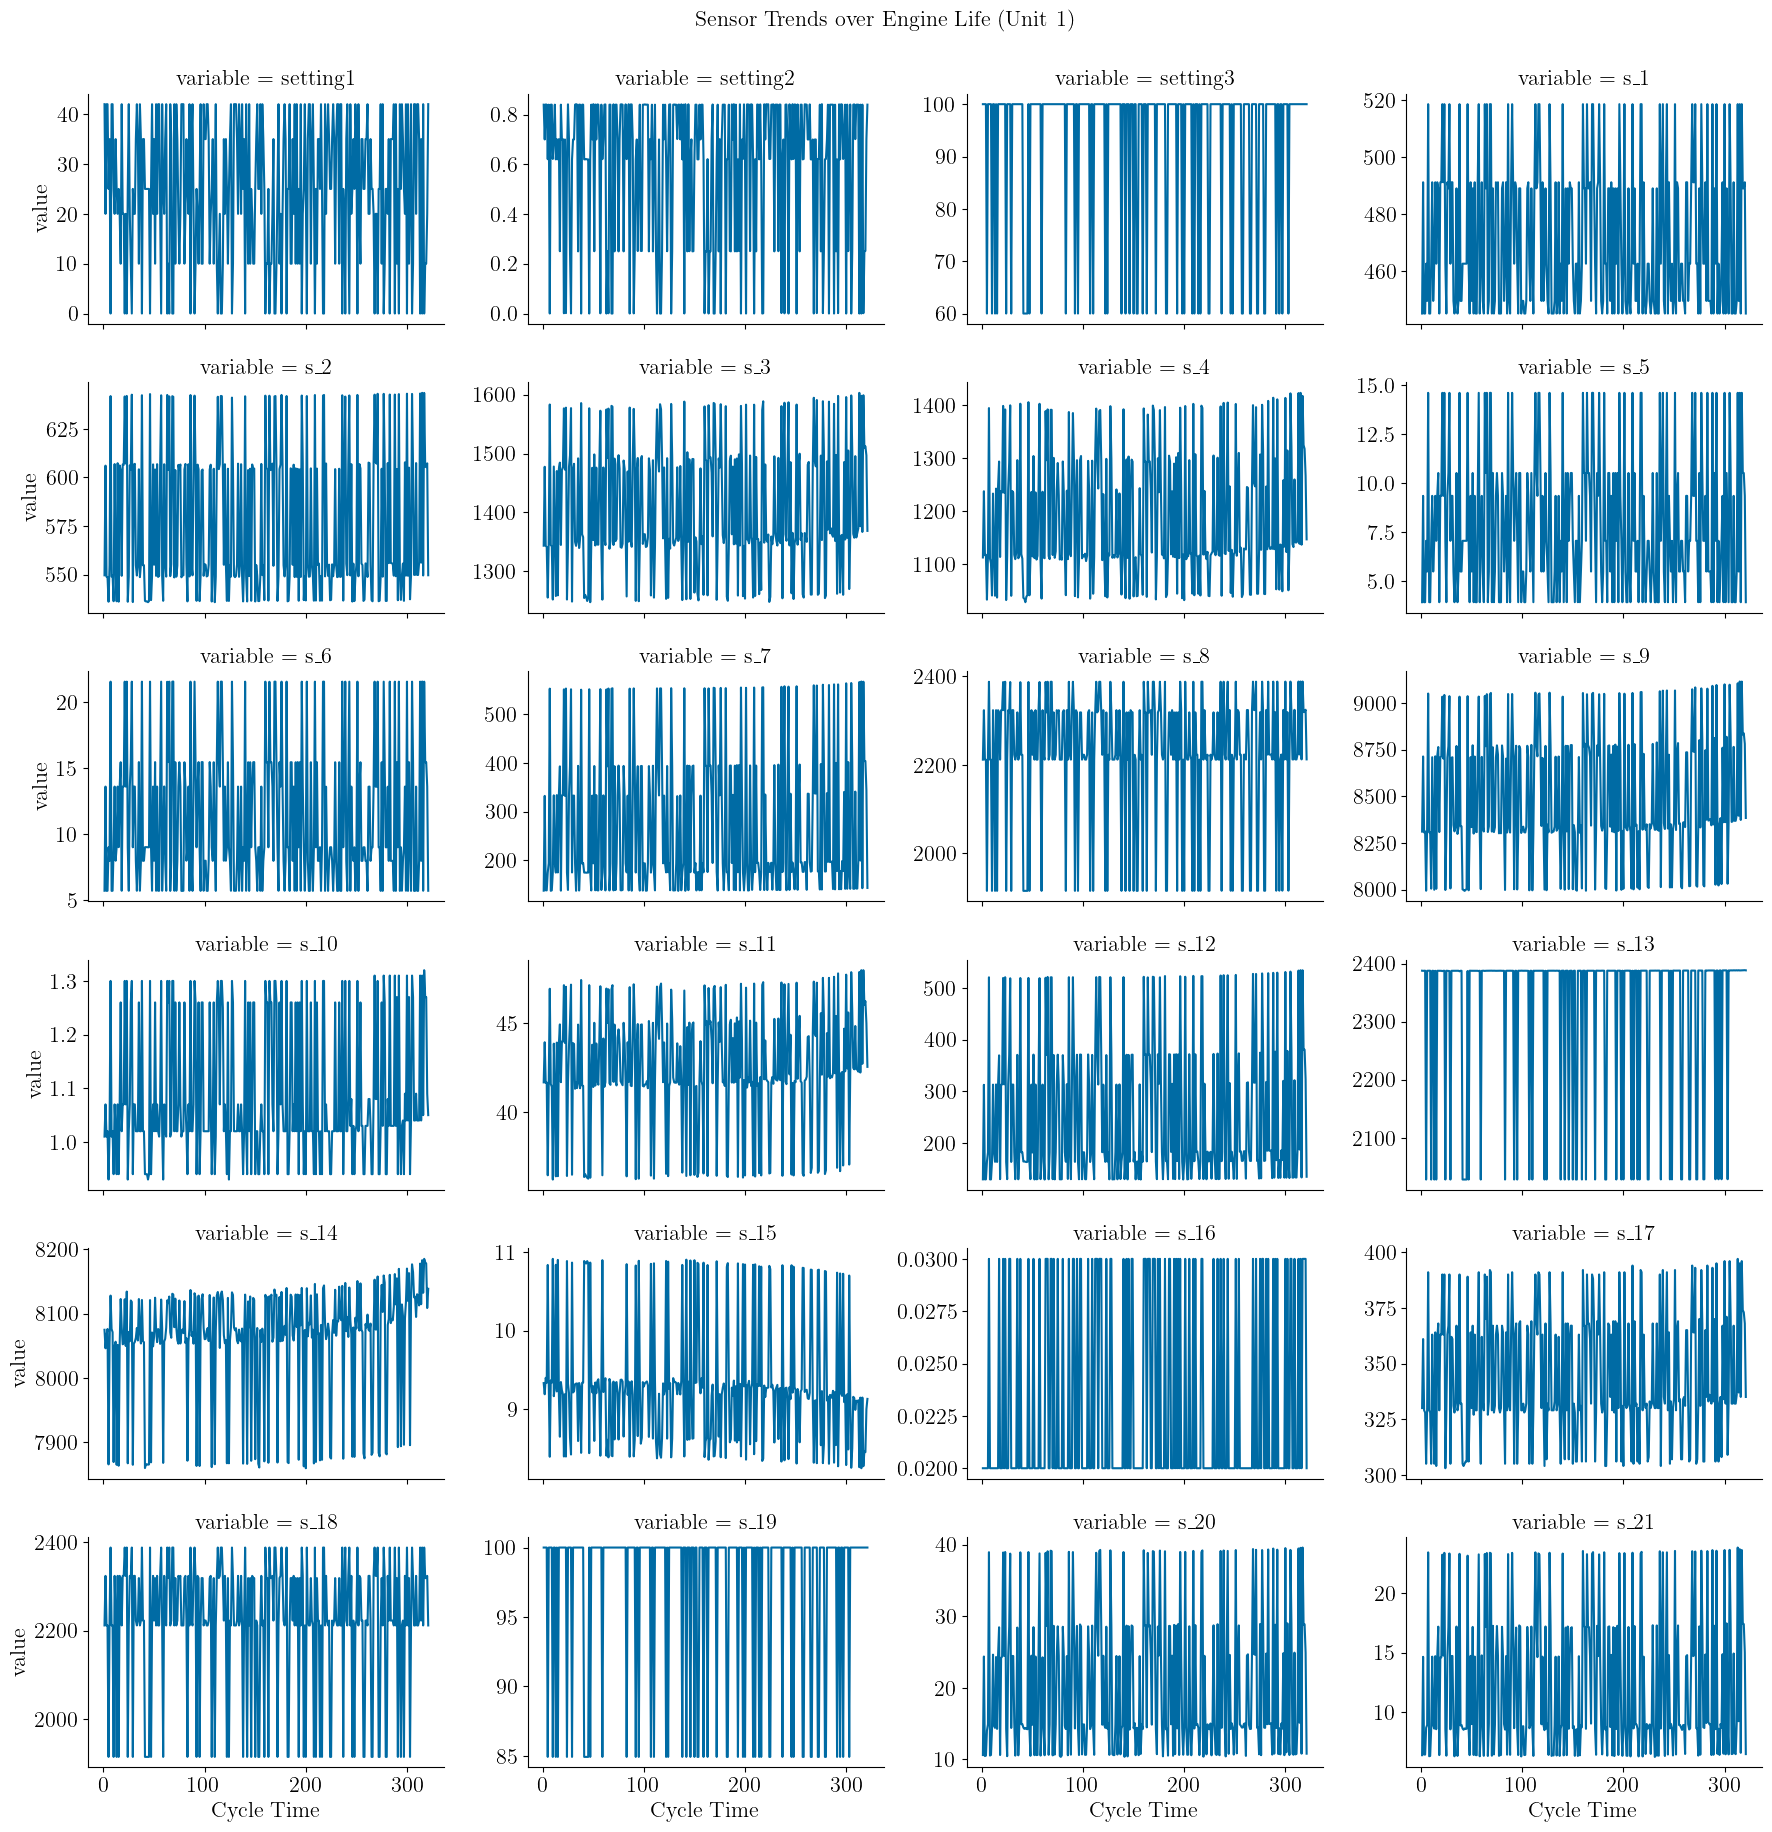

In [31]:
fig = sensor_explore_plot(df, ids='Cycle Time', values=['setting1', 'setting2', 'setting3'] + [f's_{_}' for _ in range(1, 22)])
plt.show()

Alongside removing sensors that do nothing for us, for this dataset we will make another distinction (with justification). We are going to drop any sensors that have only binary values, like Sensor 13. This is a low-variance categorical signal, acting like an on/off switch. An autoencoder learns by identifying patterns of change. Sensors that only switch between two values (like 0 and 1 once normalized) or stay constant really provide zero information about engine degradation. A fault in a turbine doesn't make the binary switch "more binary". These sensors don't trend or fluctuate as the engine wears out, so they offer no "signal" for the model to learn fault detection. We know this because we are told that the training data always goes until failure, meaning that the variables as a function of cycle time also show sensor values near or at failure. Removing this also helps prevent feature dominance in scaling and helps the autoencoder from overfitting to noise.

So, from this we can drop Sensors 13, 16, and 19. We also calculate the RUL for the training data from the difference between the max cycle and the cycle time. We do keep operational setting 3, however, because it contributes value to our possible combinations of regimes.

In [32]:
# --- 3. CALCULATE RUL FOR TRAINING DATA ---
# Since engines in the train set run to failure, RUL is (Max Cycle - Current Cycle)
max_cycles = df.groupby('Unit')['Cycle Time'].max().reset_index()
max_cycles.columns = ['Unit', 'max_cycle']
df = df.merge(max_cycles, on=['Unit'], how='left')
df['RUL'] = df['max_cycle'] - df['Cycle Time']
df.drop('max_cycle', axis=1, inplace=True)

In [33]:
# --- 4. CLEANING ---
drop_cols = ['s_13', 's_16', 's_19']
df.drop(labels=drop_cols, axis=1, inplace=True)
df_test.drop(labels=drop_cols, axis=1, inplace=True)

setting_cols = ['setting1', 'setting2', 'setting3']
sensor_cols = [c for c in df.columns if c.startswith('s_')]

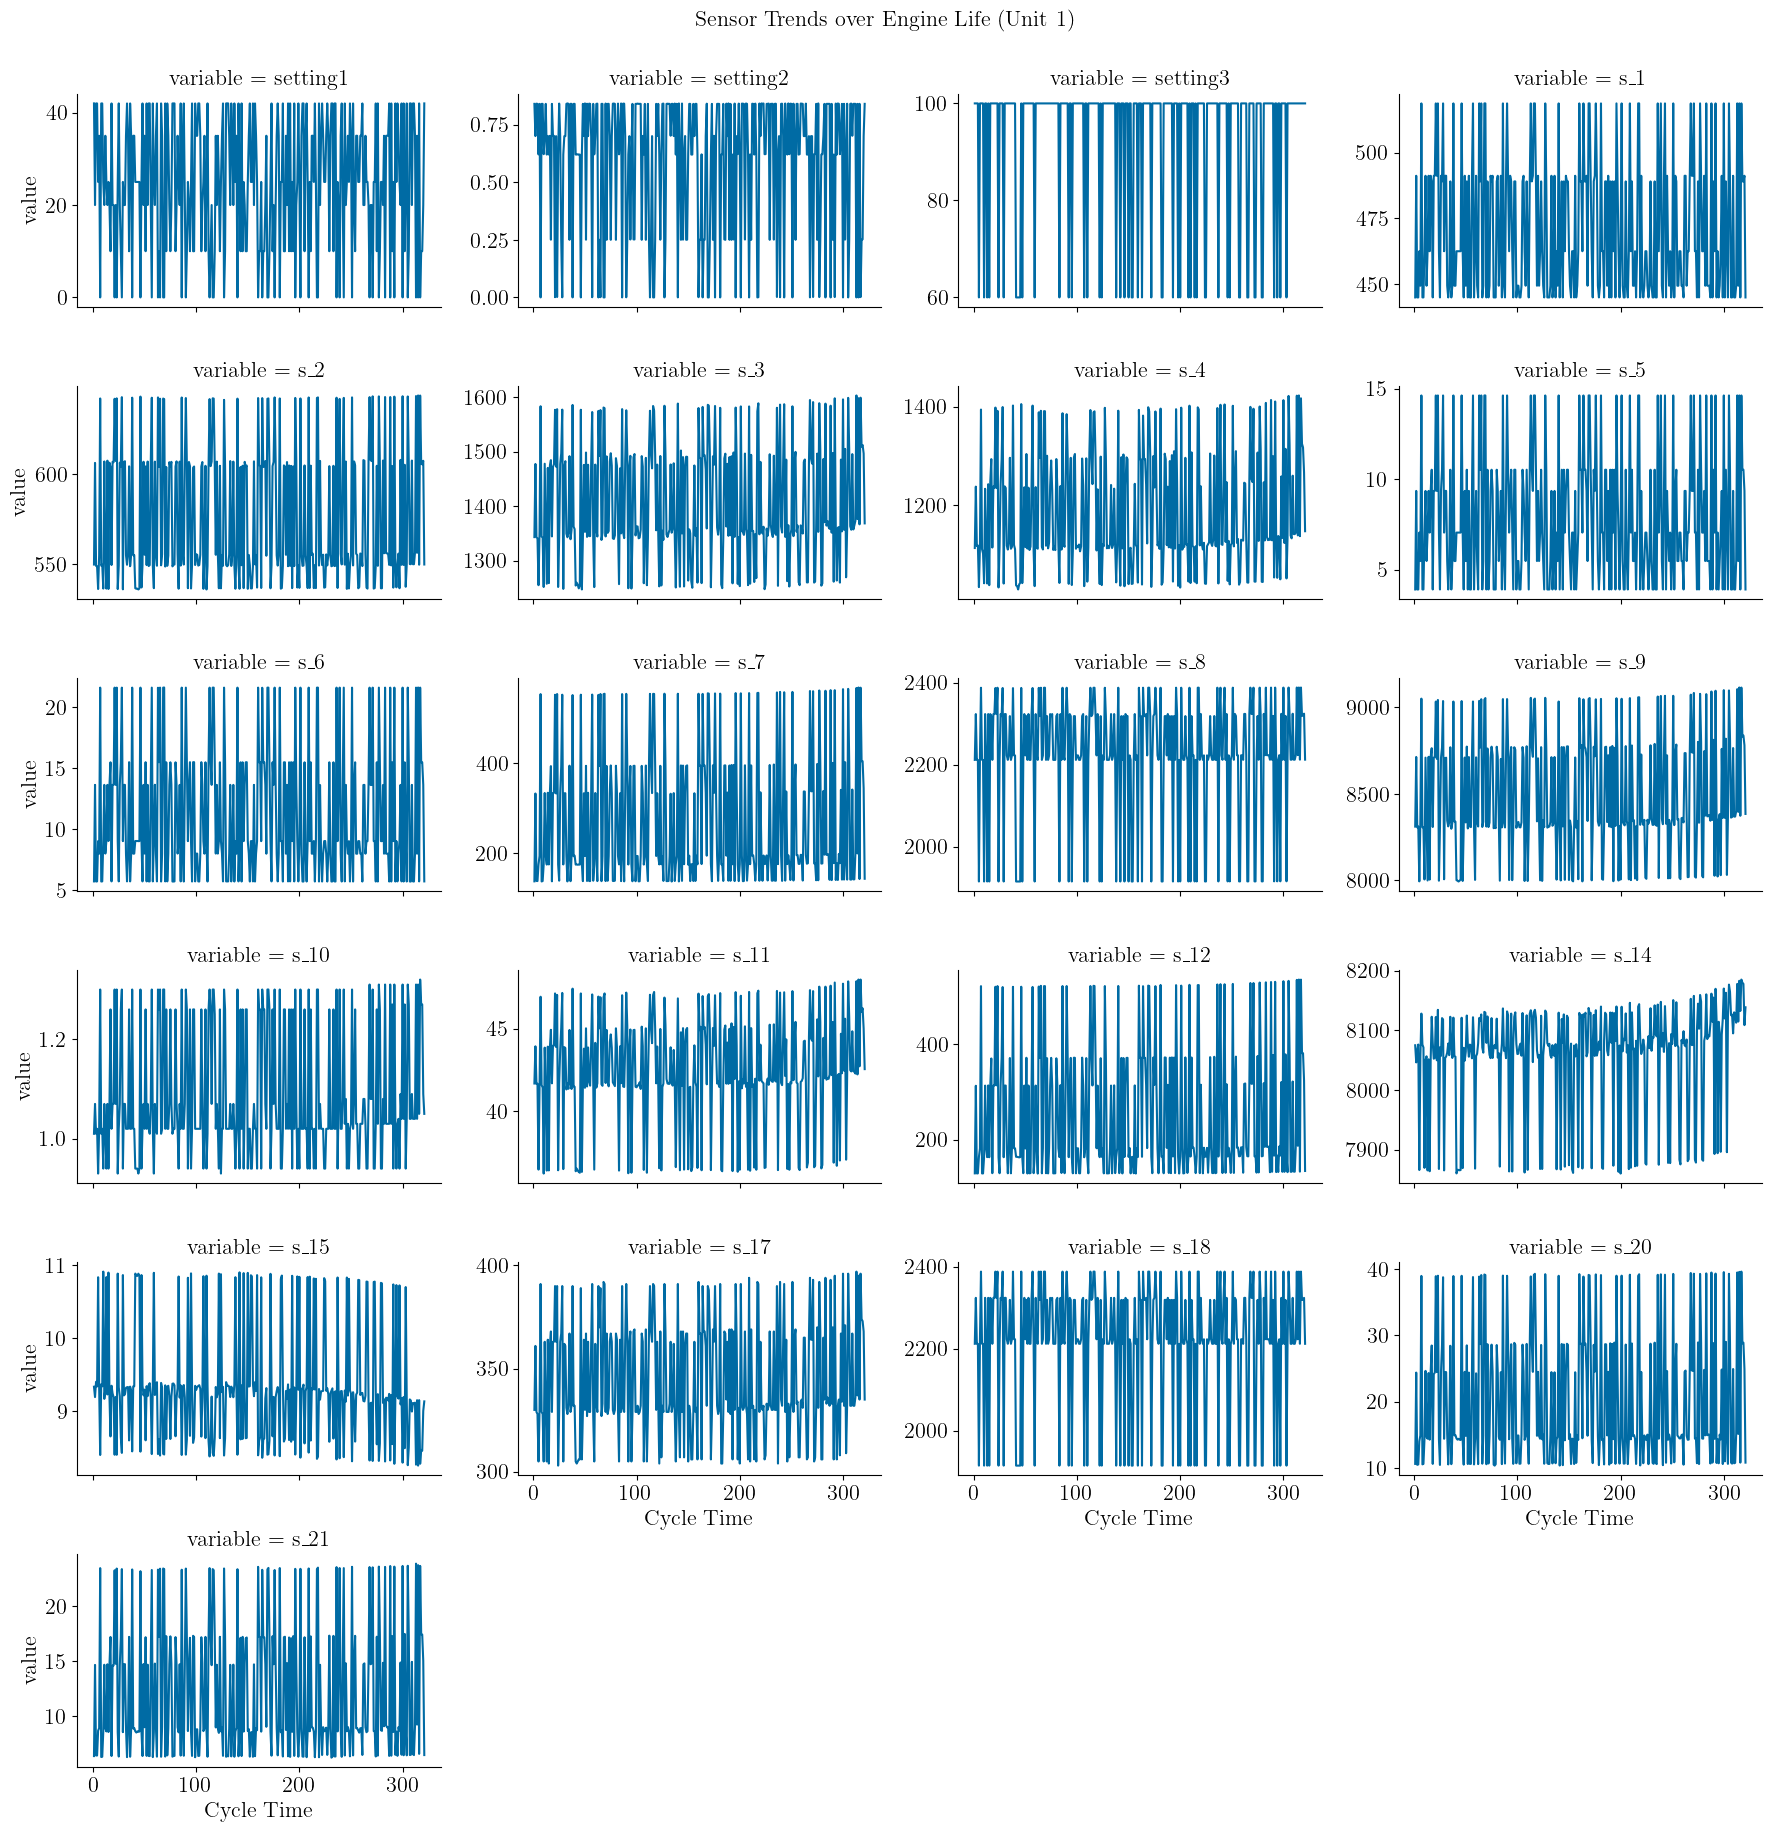

In [34]:
fig = sensor_explore_plot(df, ids='Cycle Time', values=['setting1', 'setting2', 'setting3'] + [f's_{_}' for _ in range(1, 22) if f's_{_}' not in drop_cols])
plt.show()

One thing we must note about this dataset is that for `FD004` we have many more regimes from the operational settings. In order to accurately represent the real world, we need to normalize by regime, because the data scaling relative to each other changes based on the regime.

We use K-clustering because in real life we wouldn't be able to manually inspect the data nor would you necessarily know what regime you are in. By using `KMeans`, we can get the data clustered into the six conditions based on its vector space distribution.

This is what we have implemented below.

In [35]:
# Regime-based scaling
print("Clustering operating conditions...")
# 1. Find the 6 flight conditions based on the settings
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df[setting_cols])
df_test['cluster'] = kmeans.predict(df_test[setting_cols])

# 2. Normalize the sensors WITHIN each specific cluster
healthy_mask = df['RUL'] > HEALTHY_RUL_THRESHOLD

for cluster_id in range(6):
    train_cluster_mask = df['cluster'] == cluster_id
    test_cluster_mask = df_test['cluster'] == cluster_id
    
    # Fit scaler ONLY on the healthy data of THIS specific flight condition
    scaler = StandardScaler()
    healthy_cluster_data = df[train_cluster_mask & healthy_mask][sensor_cols]
    
    # Fallback in case a specific condition has no healthy data
    if len(healthy_cluster_data) == 0:
        scaler.fit(df[train_cluster_mask][sensor_cols])
    else:
        scaler.fit(healthy_cluster_data)
    
    # Transform the data
    df.loc[train_cluster_mask, sensor_cols] = scaler.transform(df.loc[train_cluster_mask, sensor_cols])
    df_test.loc[test_cluster_mask, sensor_cols] = scaler.transform(df_test.loc[test_cluster_mask, sensor_cols])

# Now that the conditions are normalized out, our features are just the smooth sensors!
feature_cols = sensor_cols

Clustering operating conditions...


/var/folders/tk/120_6n_96y1dcp6p56ykpzd40000gn/T/ipykernel_80987/4265519503.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.29649104 -0.49936484 -1.29522071 ...  3.47991453  2.68405866
  2.68405866]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[train_cluster_mask, sensor_cols] = scaler.transform(df.loc[train_cluster_mask, sensor_cols])
/var/folders/tk/120_6n_96y1dcp6p56ykpzd40000gn/T/ipykernel_80987/4265519503.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1.29522071 -1.29522071 -1.29522071 ...  1.88820278  1.88820278
  1.09234691]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_test.loc[test_cluster_mask, sensor_cols] = scaler.transform(df_test.loc[test_cluster_mask, sensor_cols])


We get our training data for our model using the helper function `gen_sequences_and_labels`.

In [36]:
X_train_full, cycles_train, ruls_train = gen_sequences_and_labels(df, wsize, feature_cols)
healthy_idx = ruls_train > HEALTHY_RUL_THRESHOLD
X_train_healthy = X_train_full[healthy_idx]

We then define and run our LSTM Autoencoder. It is very similar to the model for `FD001`.

In [37]:
model = keras.models.Sequential([
    Input(shape=(wsize, len(feature_cols))),
    LSTM(32, activation='relu', return_sequences=False),
    RepeatVector(wsize),
    LSTM(32, activation='relu', return_sequences=True),
    TimeDistributed(Dense(len(feature_cols)))
])

model.compile(optimizer='adam', loss='mae')
print(f"Training on {len(X_train_healthy)} healthy sequences...")


Training on 17112 healthy sequences...


In [38]:

# Define the Early Stopping callback
early_stopper = keras.callbacks.EarlyStopping(
    monitor='val_loss',          # We want to watch the validation loss
    patience=5,                  # If val_loss doesn't improve for 5 epochs in a row, stop.
    min_delta=0.001,             # Minimum change required to count as an "improvement"
    restore_best_weights=True,   # CRITICAL: Revert to the best epoch's weights when stopping
    verbose=1
)

checkpoint = keras.callbacks.ModelCheckpoint(filepath='best_model_fd004.keras', monitor='val_loss', save_best_only=True)


# 1. Save the training process to a 'history' object
# Notice we added the `callbacks=[early_stopper]` argument here!
if training:
    history = model.fit(
        X_train_healthy, 
        X_train_healthy, 
        epochs=10, 
        batch_size=64, 
        validation_split=0.1, 
        callbacks=[early_stopper, checkpoint], 
        verbose=1
    )


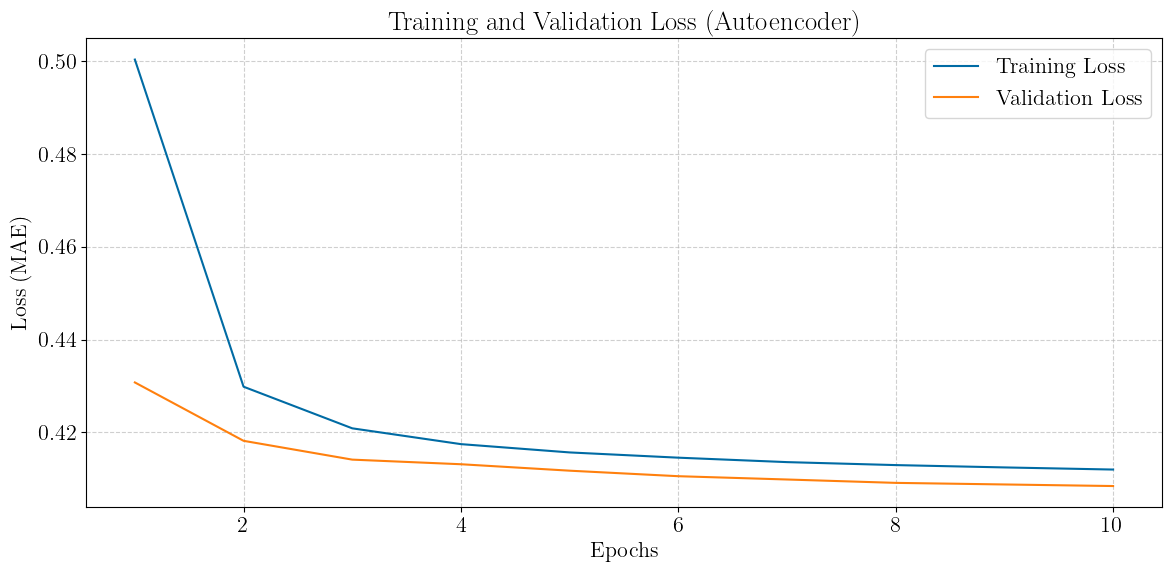

In [39]:
if training:
    fig = make_loss_plot(history)
    plt.show()
else:
    display(Image(filename='loss_fd004.png'))

In [40]:
model = keras.models.load_model('best_model_fd004.keras')

In [41]:
# --- 8. DATA-DRIVEN THRESHOLD CALCULATION ---
# Get reconstruction error for all training data
train_predictions = model.predict(X_train_full)
train_mae = np.mean(np.abs(train_predictions - X_train_full), axis=(1, 2))

# The threshold is the 99th percentile of error while the engine is STILL HEALTHY
healthy_mae = train_mae[healthy_idx]
smart_threshold = np.percentile(healthy_mae, 97.5 )
print(f"Data-Driven Failure Threshold: {smart_threshold:.4f}")


1525/1525 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Data-Driven Failure Threshold: 0.4834


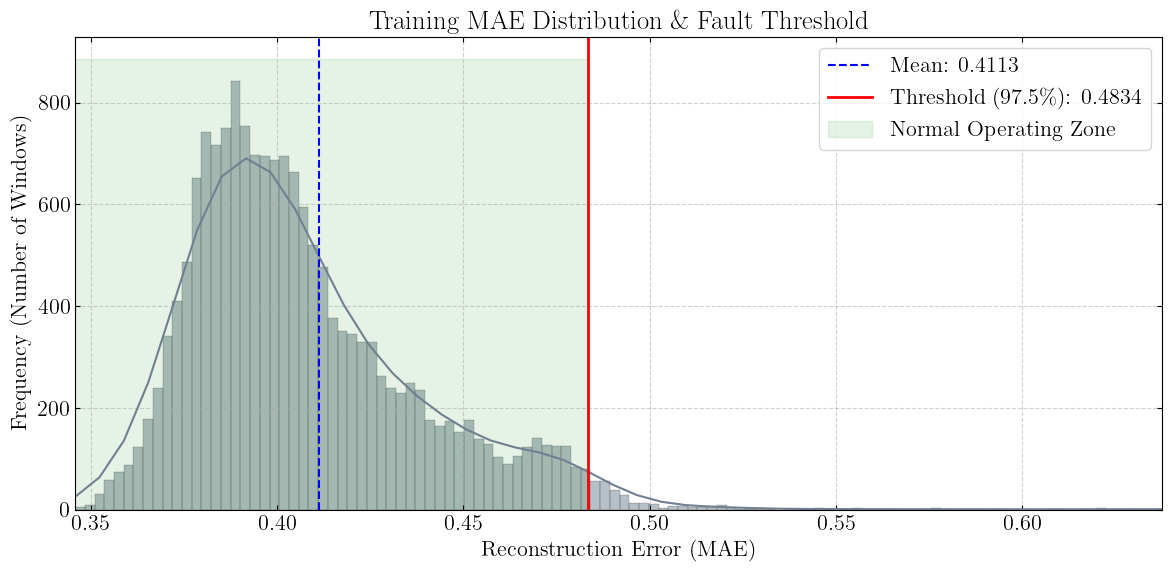

In [42]:
fig = plot_threshold_justification(healthy_mae, smart_threshold, bins=500)
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


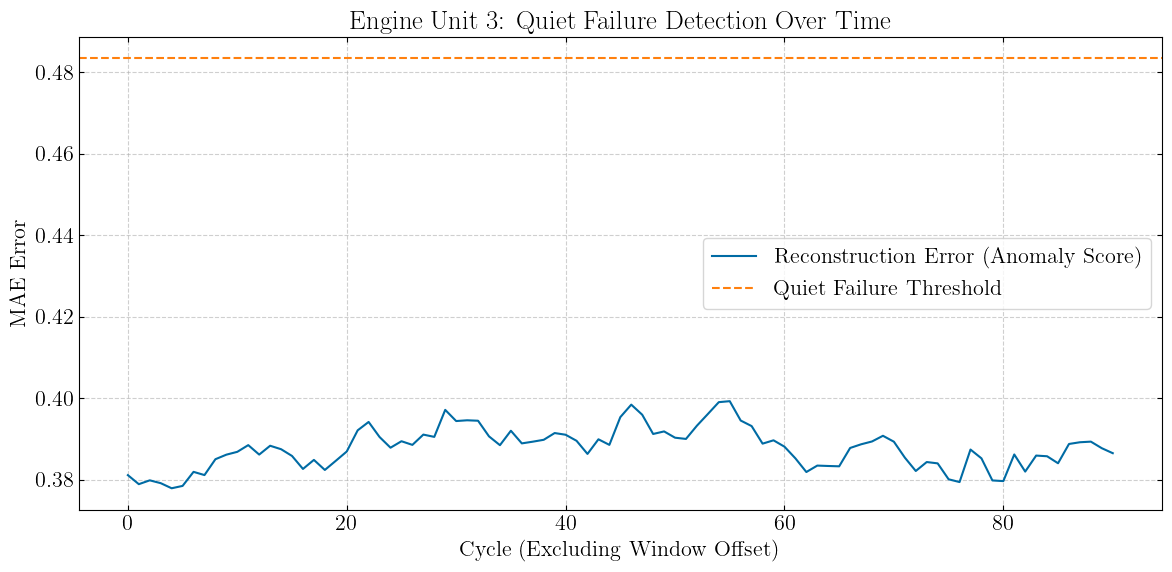

In [43]:
unit_mae, cycles_unit = failure_detection_fd004(df_test, model, 3, HEALTHY_RUL_THRESHOLD, wsize, feature_cols)
fig = failure_plot_fd004(unit_mae, smart_threshold, unit_no=3)
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


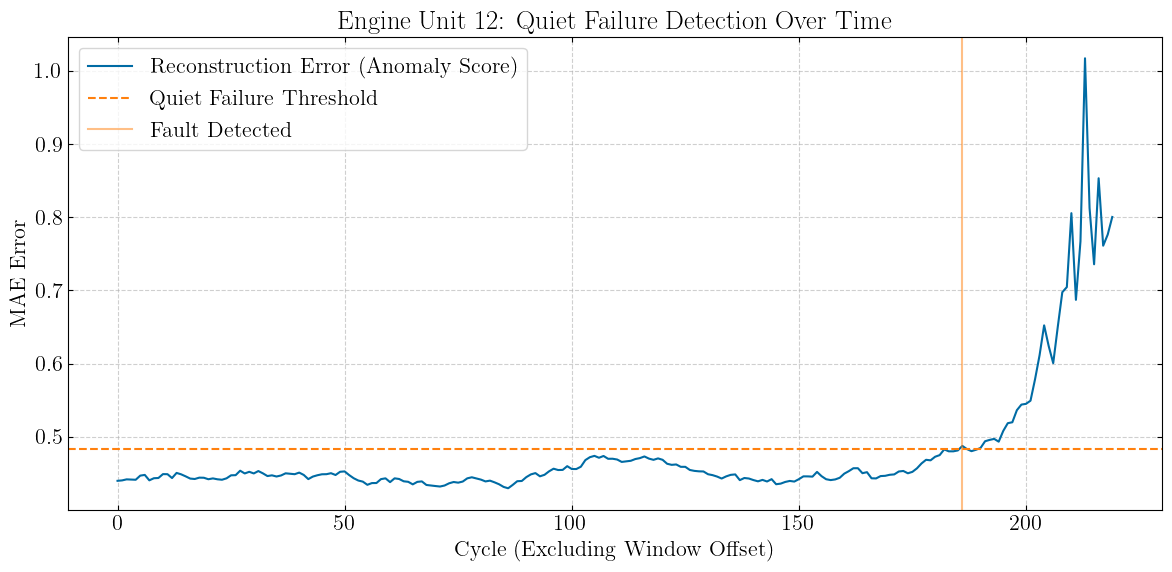

In [44]:
unit_mae, cycles_unit = failure_detection_fd004(df_test, model, 12, HEALTHY_RUL_THRESHOLD, wsize, feature_cols)
fig = failure_plot_fd004(unit_mae, smart_threshold, unit_no=12)
plt.show()

We will now do the same RUL analysis we did earlier (with a different method due to the different processing of our data)

In [45]:
print("\n--- Starting Test Set Evaluation (Peak Anomaly vs. Final RUL) ---")

# (Keep existing RUL loading and eval_df preparation)
true_rul_file = f"{path}/RUL_FD004.txt"
true_rul_df = pd.read_csv(true_rul_file, header=None, names=['True_RUL'])
true_rul_df['Unit'] = true_rul_df.index + 1

test_max_cycles = df_test.groupby('Unit')['Cycle Time'].max().reset_index()
test_max_cycles.columns = ['Unit', 'last_test_cycle']

eval_df = test_max_cycles.merge(true_rul_df, on='Unit')

# We will store one value per engine
engine_max_maes = []
engine_final_ruls = []



--- Starting Test Set Evaluation (Peak Anomaly vs. Final RUL) ---


In [46]:
print("Extracting peak MAE and Final RUL for each engine...")
for u_id in eval_df['Unit']:
    unit_mask = df_test['Unit'] == u_id
    unit_data = df_test[unit_mask]
    
    if len(unit_data) >= wsize:
        X_test_unit, _, _ = gen_sequences_and_labels(unit_data, wsize, feature_cols)
        
        # Predict and calculate MAE for the engine sequence
        unit_test_preds = model.predict(X_test_unit, verbose=0)
        unit_test_mae = np.mean(np.abs(unit_test_preds - X_test_unit), axis=(1, 2))
        
        # 1. Capture the PEAK anomaly score for this engine
        engine_max_maes.append(np.max(unit_test_mae))
        
        # 2. Capture the ground truth RUL at the end of the test data
        final_rul = eval_df.loc[eval_df['Unit'] == u_id, 'True_RUL'].values[0]
        engine_final_ruls.append(final_rul)

Extracting peak MAE and Final RUL for each engine...


Now we make that same anomaly plot we did earlier for `FD004`. We once again see a very good qualitative fit, but what we actually care about is the Spearman correlation.

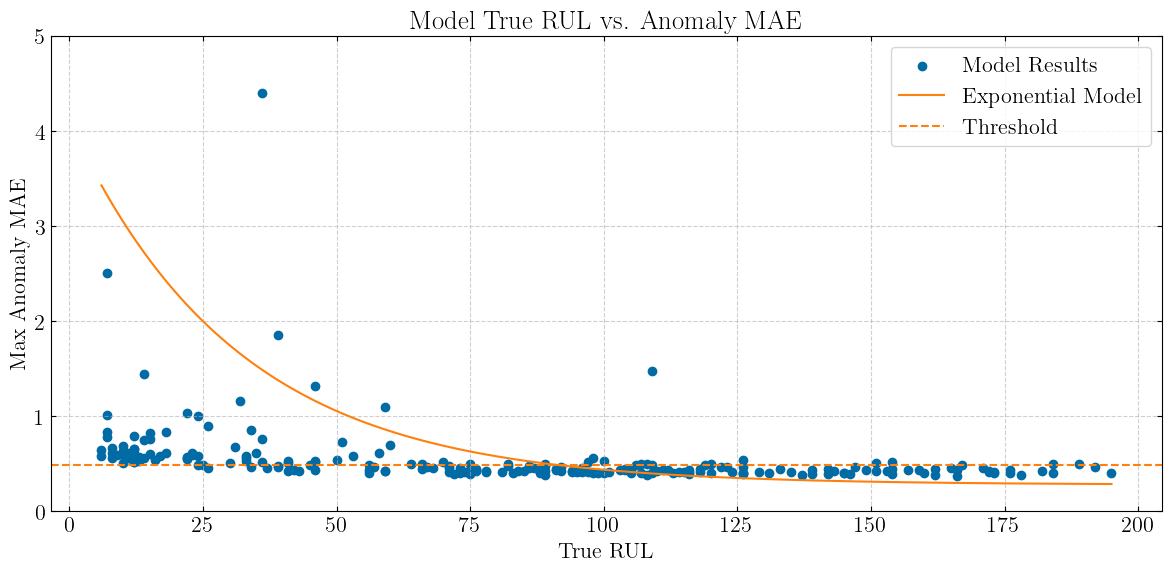

In [47]:
fig = anomaly_rul_plot_fd004(engine_final_ruls, engine_max_maes, smart_threshold)
plt.show()

We calculate the Spearman coefficient below.

In [48]:
# --- 11. CALCULATE STATISTICS ---
# We expect a NEGATIVE correlation: 
# Low RUL (near failure) should have a High Max MAE (high anomaly).
corr, p_value = spearmanr(engine_final_ruls, engine_max_maes)

print(f"\n--- ENGINE-LEVEL EVALUATION METRICS ---")
print(f"Total Engines Evaluated: {len(engine_max_maes)}")
print(f"Spearman Rank Correlation: {corr:.4f}")


--- ENGINE-LEVEL EVALUATION METRICS ---
Total Engines Evaluated: 228
Spearman Rank Correlation: -0.7023


We get a Spearman coefficient of -0.7. This is still great and a statistically significant result, meaning the trend we are seeing is numerically justified. The lower Spearman correlation in `FD004` compared to `FD001` is primarily driven by operational complexity. While `FD001` features a single, stable flight condition, `FD004` cycles through six distinct regimes, creating "shocks" in sensor data that scaling cannot perfectly smooth. Additionally, `FD004` introduces multiple failure modes (Fan and HPC degradation), meaning the model must track two different physical "death spirals" simultaneously. These factors, combined with a higher signal-to-noise ratio, create non-monotonic "jitter" in the anomaly scores, which disrupts the perfect rank-ordering required for a high Spearman value, and also decreases our Spearman value compared to `FD001`. Despite that, we only see a decrease in strength of about 0.1, which indicates a very good relationship given the complexity!